# **Modelling and Evaluation Predict Stress Level**

## Objectives

* Attempt to predict stress level by using other features from the smartwatch health data

## Inputs

* unclean_smartwatch_health_data.csv

## Outputs

* Stress Level predicting model

---

# Change working directory

We need to change the working directory from its current folder to its parent folder

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project/jupyter_notebooks'

We want to make the parent of the current directory the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project'

## Load Data

In [4]:
import pandas as pd

df = pd.read_csv('inputs/smartwatch_health_data_untouched/unclean_smartwatch_health_data.csv').drop("User ID", axis=1)
df.head()

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


In [5]:
# Change version variable to store outputs in different folder
version = "v1"

OutputFolder = f"outputs/{version}/predict_stress_level/"
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

## Cleaning and Engineering

Setup custom transformations.

In [6]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Replace 'Very High' with 10 in 'Stress Level' and convert columns to numeric
class DataTypeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Replace 'Very High' with 10 in 'Stress Level'
        X['Stress Level'] = X['Stress Level'].replace('Very High', 10)

        # Convert columns to numeric, handling non-numeric values
        X['Sleep Duration (hours)'] = pd.to_numeric(X['Sleep Duration (hours)'], errors='coerce')
        X['Stress Level'] = pd.to_numeric(X['Stress Level'], errors='coerce')

        return X


# Reduced for the discretized version of the Stress level variable, as dont need to replace 'Very High' with 10
class DataTypeTransformer2(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert columns to numeric, handling non-numeric values
        X['Sleep Duration (hours)'] = pd.to_numeric(X['Sleep Duration (hours)'], errors='coerce')
        return X

# Impute missing values (not for Activity Level)
from sklearn.impute import KNNImputer

class KNNImputerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors
        self.imputer = KNNImputer(n_neighbors=self.n_neighbors)

    def fit(self, X, y=None):
        # Identify numerical columns
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.imputer.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        # Impute numerical columns
        X[self.num_cols] = self.imputer.transform(X[self.num_cols])
        return X


# Handle Outliers
from feature_engine.outliers import Winsorizer

class WinsorizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.winsorizers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Winsorizers for each variable
        self.winsorizers['Sleep Duration (hours)'] = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.winsorizers['Heart Rate (BPM)'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.winsorizers['Blood Oxygen Level (%)'] = Winsorizer(
            capping_method='iqr', tail='left', fold=1.5, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.winsorizers['Step Count'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Winsorizers
        for winsorizer in self.winsorizers.values():
            X = winsorizer.transform(X)
        return X


class FloatToInt(BaseEstimator, TransformerMixin):
    def __init__(self, columns=['Stress Level']):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert specified columns to integer
        for col in self.columns:
            X[col] = X[col].astype(int)
        return X

# Predict missing values in 'Activity Level'
from sklearn.ensemble import RandomForestClassifier

class CategoricalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_column='Activity Level', random_state=42):
        self.target_column = target_column
        self.random_state = random_state
        self.classifier = RandomForestClassifier(random_state=self.random_state)
        self.original_categories = None

    def fit(self, X, y=None):
        X = X.copy()
        # Save original categories
        X[self.target_column] = X[self.target_column].astype('category')
        self.original_categories = X[self.target_column].cat.categories

        # Encode target column
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Split data
        self.train_data = X.dropna(subset=[self.target_column])
        self.test_data = X[X[self.target_column].isna()]

        # Features and target
        self.X_train = self.train_data.drop(columns=[self.target_column])
        self.y_train = self.train_data[self.target_column].astype(int)

        # Fit classifier
        self.classifier.fit(self.X_train, self.y_train)
        return self

    def transform(self, X):
        X = X.copy()
        # Encode target column
        X[self.target_column] = X[self.target_column].astype('category')
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Identify missing values
        missing_mask = X[self.target_column].isna()
        if missing_mask.any():
            X_missing = X[missing_mask]
            X_missing_features = X_missing.drop(columns=[self.target_column])
            # Predict missing values
            X.loc[missing_mask, self.target_column] = self.classifier.predict(X_missing_features)

        # Convert to int and decode categories
        X[self.target_column] = X[self.target_column].astype(int)
        X[self.target_column] = pd.Categorical.from_codes(
            X[self.target_column], categories=self.original_categories
        )
        return X


# Correct mis-spelled values in Activity Level
class CategoryCorrector(BaseEstimator, TransformerMixin):
    def __init__(self, column='Activity Level'):
        self.column = column
        self.class_mapping = {
            'Seddentary': 'Sedentary',
            'Highly_Active': 'Highly Active',
            'Actve': 'Active'
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = X[self.column].replace(self.class_mapping)
        return X


# Smooth data using K-Nearest Neighbors
from sklearn.neighbors import NearestNeighbors

class DataSmoother(BaseEstimator, TransformerMixin):
    def __init__(self, k=3):
        self.k = k
        self.nn = NearestNeighbors(n_neighbors=self.k)

    def fit(self, X, y=None):
        X = X.copy()
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.nn.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        distances, indices = self.nn.kneighbors(X[self.num_cols])

        # Smooth numerical columns
        for i, col in enumerate(self.num_cols):
            X[col] = [np.mean(X.iloc[indices[row_idx]][col]) for row_idx in range(len(X))]
        return X


# Trim outliers again after smoothing
from feature_engine.outliers import OutlierTrimmer

class OutlierTrimmerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.trimmers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Outlier Trimmers for each variable
        self.trimmers['Heart Rate (BPM)'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.trimmers['Blood Oxygen Level (%)'] = OutlierTrimmer(
            capping_method='quantiles', tail='left', fold=0.05, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.trimmers['Sleep Duration (hours)'] = OutlierTrimmer(
            capping_method='quantiles', tail='both', fold=0.05, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.trimmers['Step Count'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Outlier Trimmers sequentially
        for trimmer in self.trimmers.values():
            X = trimmer.transform(X)
        return X


from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
class DataFrameScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_columns=None):
        self.exclude_columns = exclude_columns
        self.scaler = MinMaxScaler()
    
    def fit(self, X, y=None):
        X_to_scale = X.drop(columns=self.exclude_columns)
        self.scaler.fit(X_to_scale)
        return self
    
    def transform(self, X):
        X_to_scale = X.drop(columns=self.exclude_columns)
        X_excluded = X[self.exclude_columns]
        X_scaled = pd.DataFrame(self.scaler.transform(X_to_scale), columns=X_to_scale.columns)
        X_final = pd.concat([X_scaled, X_excluded.reset_index(drop=True)], axis=1)
        return X_final

## ML pipeline

---

In this study, we aim to predict the Stress Level variable to determine if there is a feasible or evident method for its prediction. Alternatively, it might be more suitable to treat this as a traditional data analysis problem, which I have already explored. Based on initial findings, most variables exhibited slight correlations. However, for this particular dataset, even a modest correlation could be significant, as the acceptable correlation threshold varies between datasets. Notably, the highest observed correlation was 0.07 (between Step Count and Stress Level), which, while seemingly low, might carry considerable importance in this context.

# Finding the best algorithm for the task

Setup cleaning pipeline

In [7]:
from sklearn.pipeline import Pipeline
# encoding
from feature_engine.encoding import OrdinalEncoder 

def CleanEnginPipeline():
    cleaning_engineering_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        # I have chosen OrdinalEncoder as our categorical variables have an ordinal relationship
        ('minmax', DataFrameScaler(exclude_columns=["Activity Level", "Stress Level"])),
    ])
    return cleaning_engineering_pipeline

Fit the clean to use later.

In [8]:
df_clean = CleanEnginPipeline().fit_transform(df)
df_clean.head()

/tmp/ipykernel_12851/2474742703.py:173: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[self.column] = X[self.column].replace(self.class_mapping)


,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,0.382184,0.450366,0.264732,0.599978,0,3.000000
1,0.519542,0.544723,0.035051,0.251828,0,6.000000
2,0.080689,0.523668,0.670296,0.737055,1,2.666667
3,0.296439,0.486656,0.761901,0.260212,0,4.333333
4,0.757703,0.264152,0.496127,0.930827,0,8.000000


### Find the best algorithm for the task with GridSearchCV

In [9]:
from sklearn.pipeline import Pipeline

### Data Cleaning and Feature Engineering
from feature_engine.imputation import MeanMedianImputer
from feature_engine.imputation import CategoricalImputer
from feature_engine.encoding import OrdinalEncoder
from feature_engine.selection import SmartCorrelatedSelection

### Feat Scaling
from sklearn.preprocessing import StandardScaler

### Feat Selection
from sklearn.feature_selection import SelectFromModel

### ML algorithms 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression



def PipelineOptimization(model):
  pipeline_base = Pipeline([
      ("feat_selection",  SelectFromModel(model) ),

      ("model", model ),
    ])

  return pipeline_base


from sklearn.model_selection import GridSearchCV
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")
            model=  PipelineOptimization(self.models[key])

            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs, verbose=verbose, scoring=scoring)
            gs.fit(X,y)
            self.grid_searches[key] = gs    

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                 'estimator': key,
                 'min_score': min(scores),
                 'max_score': max(scores),
                 'mean_score': np.mean(scores),
                 'std_score': np.std(scores),
            }
            return pd.Series({**params,**d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]        
                scores.append(r.reshape(len(params),1))

            all_scores = np.hstack(scores)
            for p, s in zip(params,all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns], self.grid_searches


models_search = {
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "LinearRegression": LinearRegression(),
    "xgb": XGBRegressor(random_state=42),
}

params_search = {
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "GradientBoostingRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "LinearRegression": {},
    "xgb": {},
}

Split the data.

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_clean.drop(['Stress Level'],axis=1),
                                                    df_clean['Stress Level'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

* Train set: (6237, 5) (6237,) 
* Test set: (1560, 5) (1560,)


Perform GridSearchCV.

In [11]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring='neg_root_mean_squared_error',
           n_jobs=-1,
           cv=2)

print("Best algorithms for predicting Stress Level")
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary


Running GridSearchCV for DecisionTreeRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for LinearRegression 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for xgb 

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best algorithms for predicting Stress Level


,estimator,min_score,mean_score,max_score,std_score
3,ExtraTreesRegressor,-1.771694,-1.747544,-1.723394,0.02415
1,RandomForestRegressor,-1.785883,-1.763404,-1.740926,0.022478
2,GradientBoostingRegressor,-1.919715,-1.902376,-1.885037,0.017339
6,xgb,-1.96661,-1.918801,-1.870992,0.047809
4,AdaBoostRegressor,-1.953068,-1.934534,-1.915999,0.018534
5,LinearRegression,-1.957371,-1.937195,-1.917018,0.020176
0,DecisionTreeRegressor,-2.420211,-2.418677,-2.417142,0.001534


Extra Trees Regressor performs the best for this target variable, lets try some hyperparameters to make this better.

In [12]:
models_search = {
    'ExtraTreesRegressor': ExtraTreesRegressor(random_state=42)
}

params_search = {
    'ExtraTreesRegressor': {
        'model__n_estimators': [50, 100, 150],
        'model__min_samples_split': [15, 30, 55],
        'model__min_samples_leaf': [15, 30, 45],
        'model__criterion': ['absolute_error']
    }
}

Perform GridSearchCV with hyperparameters

In [13]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring='neg_root_mean_squared_error',
           n_jobs=-1,
           cv=2)  


# method .score_summary returns a DataFrame with all the training results summary and a dictionary containing all pipelines.
print("Best algorithms for predicting Stress Level")
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary


Running GridSearchCV for ExtraTreesRegressor 

Fitting 2 folds for each of 27 candidates, totalling 54 fits
Best algorithms for predicting Stress Level


,estimator,min_score,mean_score,max_score,std_score,model__criterion,model__min_samples_leaf,model__min_samples_split,model__n_estimators
2,ExtraTreesRegressor,-1.936847,-1.917669,-1.898491,0.019178,absolute_error,15,15,150
5,ExtraTreesRegressor,-1.936847,-1.917669,-1.898491,0.019178,absolute_error,15,30,150
1,ExtraTreesRegressor,-1.936839,-1.918052,-1.899266,0.018786,absolute_error,15,15,100
4,ExtraTreesRegressor,-1.936839,-1.918052,-1.899266,0.018786,absolute_error,15,30,100
0,ExtraTreesRegressor,-1.935681,-1.918105,-1.90053,0.017575,absolute_error,15,15,50
3,ExtraTreesRegressor,-1.935681,-1.918105,-1.90053,0.017575,absolute_error,15,30,50
8,ExtraTreesRegressor,-1.942741,-1.923736,-1.904731,0.019005,absolute_error,15,55,150
7,ExtraTreesRegressor,-1.942361,-1.923778,-1.905194,0.018584,absolute_error,15,55,100
6,ExtraTreesRegressor,-1.941451,-1.924296,-1.90714,0.017155,absolute_error,15,55,50
16,ExtraTreesRegressor,-1.948835,-1.929525,-1.910215,0.01931,absolute_error,30,55,100


Save the best model and parameters.

In [14]:
best_model = grid_search_summary.iloc[0, 0]
grid_search_pipelines[best_model].best_params_
best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline

Pipeline(steps=[('feat_selection',
                 SelectFromModel(estimator=ExtraTreesRegressor(random_state=42))),
                ('model',
                 ExtraTreesRegressor(criterion='absolute_error',
                                     min_samples_leaf=15, min_samples_split=15,
                                     n_estimators=150, random_state=42))])

Assess feature importance

* The pipeline has 6 features after data cleaning and feature engineering.
* These are the 4 most important features in descending order. The model was trained on them: 
['Step Count', 'Heart Rate (BPM)', 'Sleep Duration (hours)', 'Blood Oxygen Level (%)']


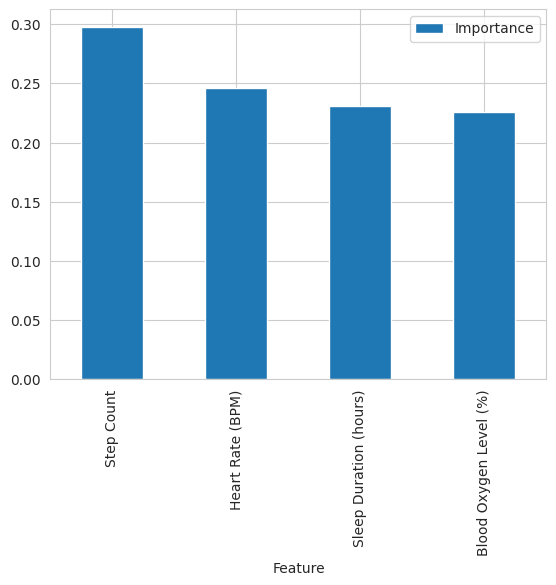

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# after data cleaning and feature engineering, the features may have changes
# how many data cleaning and feature engineering steps does your pipeline have?
columns_after_data_cleaning_feat_eng = df_clean.columns.to_list()
print(f"* The pipeline has {len(columns_after_data_cleaning_feat_eng)} features after data cleaning and feature engineering.")

# Ensure the indices are within bounds
support = best_regressor_pipeline['feat_selection'].get_support()
best_features = [columns_after_data_cleaning_feat_eng[i] for i in range(len(support)) if support[i]]

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': best_features,
    'Importance': best_regressor_pipeline['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{df_feature_importance['Feature'].to_list()}")

df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.savefig(OutputFolder + 'feature_importance_regression.png')
plt.show()

Assess performance metrics

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

counter = 0


def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)


def regression_evaluation(X, y, pipeline):
    prediction = pipeline.predict(X)
    print('R2 Score:', r2_score(y, prediction).round(3))
    print('Mean Absolute Error:', mean_absolute_error(y, prediction).round(3))
    print('Mean Squared Error:', mean_squared_error(y, prediction).round(3))
    print('Root Mean Squared Error:', np.sqrt(
        mean_squared_error(y, prediction)).round(3))
    print("\n")


def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    global counter
    counter += 1
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train, y=y_train, color='red', ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")

    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test, y=y_test, color='red', ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Test Set")

    filename = os.path.join(OutputFolder, f'regression_evaluation_plots_{counter}.png')
    plt.savefig(filename)
    plt.show()

Model Evaluation 

* Train Set
R2 Score: 0.118
Mean Absolute Error: 1.492
Mean Squared Error: 3.305
Root Mean Squared Error: 1.818


* Test Set
R2 Score: 0.039
Mean Absolute Error: 1.589
Mean Squared Error: 3.658
Root Mean Squared Error: 1.913




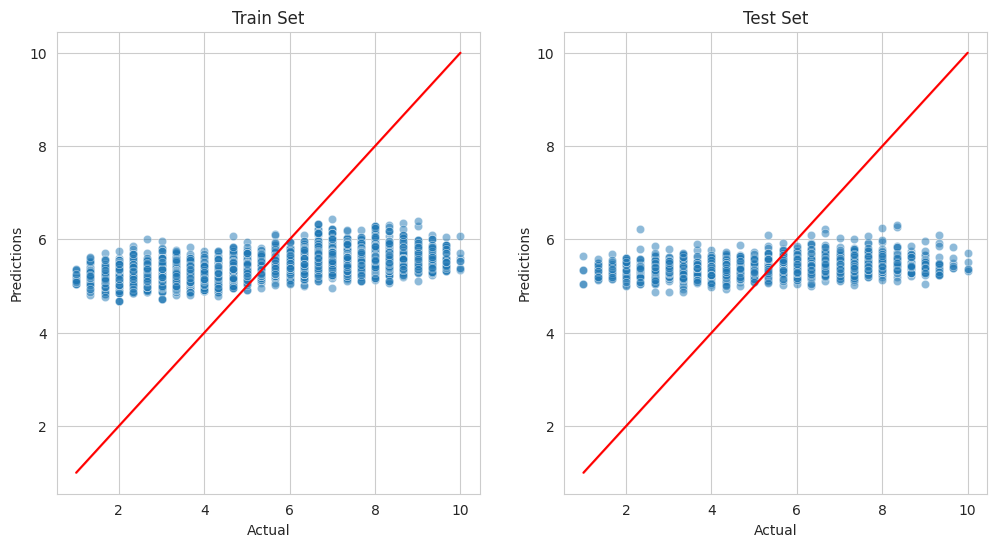

In [17]:
regression_performance(X_train, y_train, X_test, y_test, best_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test, best_regressor_pipeline)

---

## Regression with PCA

Lets see how Stress Level performs with PCA regression.

Setup pipeline with PCA.

In [ ]:
from sklearn.decomposition import PCA

def PCAPipeline():
    pca_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        ('minmax', DataFrameScaler(exclude_columns=["Activity Level", "Stress Level"])),
        ('pca', PCA(n_components=4, random_state=42))
    ])
    return pca_pipeline

Fit the pipeline and PCA.

In [ ]:
pipeline = PCAPipeline()
pipeline_pca = Pipeline(pipeline.steps[:11])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, '\n', type(df_pca))

Assess components.

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

n_components = 3


def pca_components_analysis(df_pca, n_components):
    pca = PCA(n_components=n_components).fit(df_pca)
    x_PCA = pca.transform(df_pca)

    ComponentsList = ["Component " + str(number)
                      for number in range(n_components)]
    dfExplVarRatio = pd.DataFrame(
        data=np.round(100 * pca.explained_variance_ratio_, 3),
        index=ComponentsList,
        columns=['Explained Variance Ratio (%)'])

    dfExplVarRatio['Accumulated Variance'] = dfExplVarRatio['Explained Variance Ratio (%)'].cumsum(
    )

    PercentageOfDataExplained = dfExplVarRatio['Explained Variance Ratio (%)'].sum(
    )

    print(
        f"* The {n_components} components explain {round(PercentageOfDataExplained,2)}% of the data \n")
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=dfExplVarRatio,  marker="o")
    plt.xticks(rotation=90)
    plt.yticks(np.arange(0, 110, 10))
    plt.savefig(OutputFolder + 'pca_components_analysis.png')
    plt.show()


pca_components_analysis(df_pca=df_pca, n_components=n_components)

Setup potential algorithms.

In [ ]:
models_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    "XGBRegressor": XGBRegressor(random_state=0),
}

params_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    "XGBRegressor": {},
}

Fit pipeline again but now with the optimal components.

In [ ]:
pipeline = PCAPipeline()
pipeline_pca = Pipeline(pipeline.steps[:10])
df_pca = pipeline_pca.fit_transform(df)
df_pca.drop('Stress Level', axis=1, inplace=True)

df_pca = PCA(n_components=4).fit_transform(df_pca)

Split the data.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_pca,
                                                    df_clean['Stress Level'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

Perform a GridSearchCV.

In [ ]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train,
           y_train,
           scoring='neg_root_mean_squared_error',
           n_jobs=-1,
           cv=5)

grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary

Grab best model and parameters.

In [ ]:
best_model = grid_search_summary.iloc[0,0]
grid_search_pipelines[best_model].best_params_

best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline

Check performance metrics.

In [ ]:
regression_performance(X_train, y_train, X_test, y_test,best_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test,
                            best_regressor_pipeline)

This hasn't performed very well, I would have liked to have spent more time adjusting hyperparameters and such, but time is not plentiful.

## Convert to a classification task

Finally lets turn this into a classification task and see if the results improve.

Setup classification pipeline.

In [ ]:

def CleanEnginPipelineDisc():
    cleaning_engineering_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        ('minmax', DataFrameScaler(exclude_columns=["Stress Level"])),
    ])
    return cleaning_engineering_pipeline

Split the data.

In [ ]:
pipeline = CleanEnginPipelineDisc()
df_discret = pipeline.fit_transform(df)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_discret.drop(columns=['Stress Level']),
                                                    df_discret['Stress Level'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

I decided to use the Arbitrary Discretiser and split Stress Level into intergers between zero and ten.

In [ ]:
from feature_engine.discretisation import ArbitraryDiscretiser

stress_map = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
disc = ArbitraryDiscretiser(binning_dict={'Stress Level': stress_map}, return_object=True)
y_train = disc.fit_transform(y_train.to_frame())
y_test = disc.transform(y_test.to_frame())

disc.binner_dict_['Stress Level']

n_classes = len(stress_map) - 1
classes_ranges = disc.binner_dict_['Stress Level'][1:-1]

labels_map = {}
for n in range(0, n_classes):
    if n == 0:
        labels_map[n] = f"<{classes_ranges[0]}"
    elif n == n_classes-1:
        labels_map[n] = f"+{classes_ranges[-1]}"
    else:
        labels_map[n] = f"{classes_ranges[n-1]} to {classes_ranges[n]}"

labels_map

y_train = y_train.replace(labels_map)
y_test = y_test.replace(labels_map)
y_train.head(20)


layout potential classifier algorithms.

In [ ]:
models_search = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
}

params_search = {
    "DecisionTreeClassifier": {},
    "RandomForestClassifier": {},
    "GradientBoostingClassifier": {},
    "ExtraTreesClassifier": {},
    "AdaBoostClassifier": {},
}

Perform GrisSearchCV for a classification task.

In [ ]:
# Convert numeric bins to string labels
y_train = y_train.astype(str)
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train.values.ravel(),
                 cv=3,
                 n_jobs=-1,
                 verbose=1,
                 scoring='accuracy')

Save the best model and parameters.

In [ ]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
best_model = grid_search_summary.iloc[0,0]
pipeline_clf = grid_search_pipelines[best_model].best_estimator_
grid_search_summary

Check feature importance calculated by the model.

In [ ]:
import matplotlib.pyplot as plt
columns_after_data_cleaning_feat_eng = df_clean.columns.to_list()
print(f"* The pipeline has {len(columns_after_data_cleaning_feat_eng)} features after data cleaning and feature engineering.")

# Ensure the indices are within bounds
support = pipeline_clf['feat_selection'].get_support()
best_features = [columns_after_data_cleaning_feat_eng[i] for i in range(len(support)) if support[i]]

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': best_features,
    'Importance': pipeline_clf['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)


print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{df_feature_importance['Feature'].to_list()}")

df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.savefig(OutputFolder + 'feature_importance_classification.png')
plt.show()

It seems step count is the best predictor for Stress Level as a categoric datatype

Lets check the performance metrics. Load in the assessment function for classification.

In [ ]:
import os
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import sys

# Set output folder directly
output_folder = OutputFolder  # Ensure this is a valid directory

def confusion_matrix_and_report(X, y, pipeline, label_map, file):
    prediction = pipeline.predict(X)

    # Write the confusion matrix to the file
    file.write('---  Confusion Matrix  ---\n')
    file.write(pd.DataFrame(confusion_matrix(y_true=prediction, y_pred=y),
                            columns=["Actual " + sub for sub in label_map],
                            index=["Prediction " + sub for sub in label_map]
                            ).to_string())
    file.write("\n\n")

    # Write the classification report to the file
    file.write('---  Classification Report  ---\n')
    file.write(classification_report(y, prediction, target_names=label_map))
    file.write("\n\n")


def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    # Ensure the output folder exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Specify the output file path
    output_path = os.path.join(output_folder, 'classification_report.txt')

    # Open the output file in write mode
    with open(output_path, 'w') as file:
        file.write("#### Train Set #### \n\n")
        confusion_matrix_and_report(X_train, y_train, pipeline, label_map, file)

        file.write("#### Test Set ####\n\n")
        confusion_matrix_and_report(X_test, y_test, pipeline, label_map, file)

    # Print the results to the console
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map, sys.stdout)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map, sys.stdout)

    print(f"Results saved to: {output_path}")


Put together the classifier.

In [ ]:
def DiscretPipeline():
    pipeline = Pipeline([
        ('feature_selection', SelectFromModel(estimator=ExtraTreesClassifier())),
        ('model',  ExtraTreesClassifier())
    ])
    return pipeline

Fit pipeline and assess performance.

In [ ]:
pipeline = DiscretPipeline()

y_train = y_train.astype(str)
y_test = y_test.astype(str)

pipeline.fit(X_train, y_train.values.ravel())

label_map = [str(label) for label in y_train.value_counts().index.to_list()]


clf_performance(X_train=X_train, y_train=y_train.values.ravel(),
                X_test=X_test, y_test=y_test.values.ravel(),
                pipeline=pipeline,
                label_map=label_map)

This classification version of the task has performed the best. Lets build it fully and save it.

## Best pipeline

In [ ]:
# Save the discretized data
df_discret.to_csv(OutputFolder + 'discretized_smartwatch_health_data.csv', index=False)

Setup final pipeline.

In [ ]:
def FullDiscretPipeline():
    best_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        ('minmax', DataFrameScaler(exclude_columns=["Stress Level"])),
    ])
    return best_pipeline

Construct final classifier.

In [ ]:
def DiscretPipelineModel():
    pipeline = Pipeline([
        ('feature_selection', SelectFromModel(estimator=ExtraTreesClassifier())),
        ('model',  ExtraTreesClassifier())
    ])
    return pipeline

Split the data and discretise the target Stress Level.

In [ ]:
best_pipeline = FullDiscretPipeline()
df_discret = best_pipeline.fit_transform(df)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_discret.drop(columns=['Stress Level']),
                                                    df_discret['Stress Level'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

stress_map = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
disc = ArbitraryDiscretiser(binning_dict={'Stress Level': stress_map}, return_object=True)
y_train = disc.fit_transform(y_train.to_frame())
y_test = disc.transform(y_test.to_frame())

disc.binner_dict_['Stress Level']

n_classes = len(stress_map) - 1
classes_ranges = disc.binner_dict_['Stress Level'][1:-1]

labels_map = {}
for n in range(0, n_classes):
    if n == 0:
        labels_map[n] = f"<{classes_ranges[0]}"
    elif n == n_classes-1:
        labels_map[n] = f"+{classes_ranges[-1]}"
    else:
        labels_map[n] = f"{classes_ranges[n-1]} to {classes_ranges[n]}"
        

y_train = y_train.replace(labels_map)
y_test = y_test.replace(labels_map)
y_train.head(20)

best_pipeline_modeler = DiscretPipelineModel()
best_pipeline_modeler.fit(X_train, y_train)

Assess final performance.

In [ ]:
clf_performance(X_train=X_train, y_train=y_train.values.ravel(),
                X_test=X_test, y_test=y_test.values.ravel(),
                pipeline=pipeline,
                label_map=label_map)

Save model

In [ ]:
import joblib
joblib.dump(best_pipeline_modeler, OutputFolder + 'discretized_smartwatch_health_data_model.pkl')

---

Great! It would seem for predicting both Step Count and Stress Level both seem to prefer and perform better as a categoric problem. This will be noted and elaborated in the dashboard for this task.

---